In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [2]:
n_samples = 500
x = 50* np.random.rand(n_samples,1)
y = 2.5*x + 10

noise = np.random.rand(n_samples,1) * 25
y = y + noise 


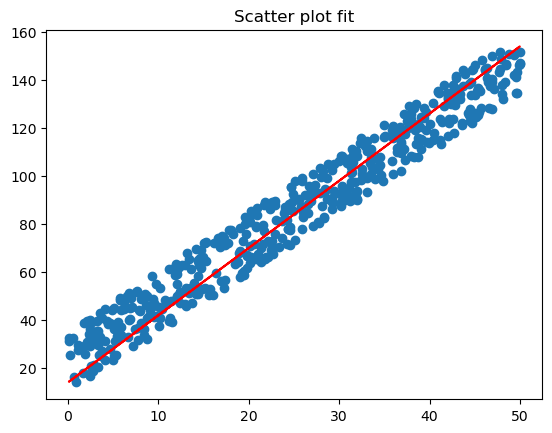

In [3]:
def ideal_plot_fit(x,y):

    plt.figure()
    plt.scatter(x,y)
    plt.plot(x, 2.8*x + 14, c='red')
    plt.title('Scatter plot fit')
    plt.show()

ideal_plot_fit(x,y)

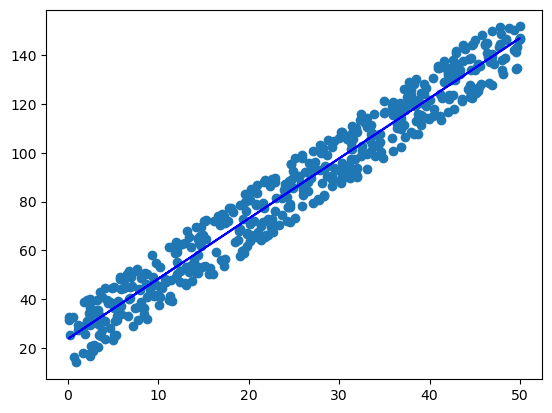

In [4]:
def linear_fit_model(x,y):

    # y_pred = slope * x + intercept
    # j = (y - y_pred)**2
    # return j

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator = np.sum((x - x_mean)*(y-y_mean))
    denominator = np.sum((x - x_mean)**2)

    slope = numerator/denominator

    intercept = y_mean - slope * x_mean

    return slope, intercept
slope, intercept = linear_fit_model(x,y)

plt.scatter(x,y)
plt.plot(x, slope*x + intercept,color='blue')
# plt.scatter(x,least_square,c='red')
plt.show()


    

In [5]:
slope, intercept

(np.float64(2.4667660782659477), np.float64(23.666460375045553))

In [6]:
from matplotlib.animation import FuncAnimation
import matplotlib
# matplotlib.use('TkAgg') # <--- Forces a separate popup window on Mac
from IPython.display import display, clear_output

In [7]:
init_slope = 1.8
init_intercept = 0
num_samples = len(x)
learning_rate = 0.01
epochs = 200


def gradient_descent_algorithm(x,y,slope, intercept, num_samples, learning_rate, epochs):


    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)



    m = slope 
    b = intercept 
    n = num_samples


    # print('Init slope intercept',m,b)

    init_cost_function =  (1/2*n)*np.sum((y - m*x - b)**2)
    # print(init_cost_function)


# 3. Setup the Plot
    plt.ion()  # <--- CRITICAL: Turns on interactive mode
    fig, ax = plt.subplots(2,1,figsize=(10, 10))
    ax[0].scatter(x, y, color='blue', label='Data Points', alpha=0.5)
    line, = ax[0].plot([], [], 'r-', lw=2, label='Current Fit') # Empty line to update
    ax[0].set_title("Gradient Descent: Linear Regression")
    ax[0].legend()



    loss_iter = []
    for i in range(0,epochs):

        y_pred = m*x + b

        dm = ((-2/n)*np.sum((x)*(y - y_pred))) # ---> Slope
        db = ((-2/n)*np.sum(y - y_pred)) # ---> Intercept

        m = m - learning_rate * dm

        b = b - learning_rate * db

        y_pred_temp = m * x + b
        y_pred = y_pred_temp
        initial_pred = y_pred_temp

        line.set_data(x, y_pred.flatten())

        fig.canvas.draw()
        fig.canvas.flush_events()
        plt.pause(0.05) # Pause to let the GUI catch up
        ax[0].set_title(f"Epoch {i}: m={m:.2f}, b={b:.2f}")
    

        loss =  (1/2*n)*np.sum((y - m*x - b)**2)

        loss_iter.append(loss)

        ax[1].set_title('Loss')
        ax[1].plot(np.arange(0,i+1),loss_iter)
        ax[1].set_ylim(3000,100000)
        ax[1].set_xlim(0,epochs + 100)
        ax[1].set_yscale('log')
        

        display(fig)       # Draw the figure
        clear_output(wait=True) # Clear it for the next frame
        plt.pause(0.01)    # Small pause to limit framerate

        # print(f"Loss: {loss}")

    plt.ioff()
    plt.show()

    print(f"Initial slope intercept: {slope, intercept}")
    print('Final slope intercept: ',m,b)




    return m,b

m,b = gradient_descent_algorithm(x,y,init_slope, init_intercept, num_samples,learning_rate,epochs)

Initial slope intercept: (1.8, 0)
Final slope intercept:  0.9927594290035331 -1.1051604076328656e-16


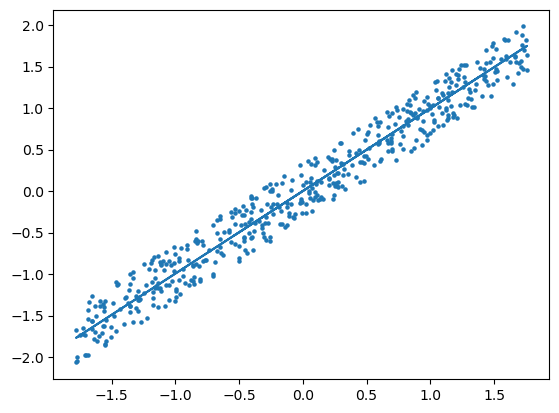

In [8]:
from matplotlib.animation import FuncAnimation
import matplotlib
# matplotlib.use('TkAgg') # <--- Forces a separate popup window on Mac
from IPython.display import display, clear_output

In [ ]:
true_slope = 3.5
true_intercept = 10
num_points = 50

# 2. Generate Random X values (e.g., between 0 and 10)
xt = np.random.rand(num_points) * 10 

# 3. Generate Random Noise (Gaussian/Normal distribution)
# "scale" determines how scattered the points are
noise = np.random.normal(loc=0, scale=3.0, size=num_points) 

# 4. Generate Y values
# y = mx + b + noise
yt = (true_slope * xt) + true_intercept + noise

plt.scatter(x,y,s=4)
plt.show()